In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

htb_green = "#9fef00"
node_black = "#141d2b"
hacker_grey = "#a4b1cd"
white = "#ffffff"
azure = "#0086ff"
nugget_yellow = "#ffaf00"
malware_red = "#ff3e3e"
vivid_purple = "#9f00ff"
aquamarine = "#2ee7b6"

# Configure plot styles
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update(
    {
        "figure.facecolor": node_black,
        "axes.facecolor": node_black,
        "axes.edgecolor": hacker_grey,
        "axes.labelcolor": white,
        "text.color": white,
        "xtick.color": hacker_grey,
        "ytick.color": hacker_grey,
        "grid.color": hacker_grey,
        "grid.alpha": 0.1,
        "legend.facecolor": node_black,
        "legend.edgecolor": hacker_grey,
        "legend.frameon": True,
        "legend.framealpha": 1.0,
        "legend.labelcolor": white,
    }
)

# Seed for reproducibility
SEED = 1337
np.random.seed(SEED)

print("Setup complete. Libraries imported and styles configured.")

Setup complete. Libraries imported and styles configured.


In [2]:
# Generate synthetic data
n_samples = 1000
centers = [(0, 5), (5, 0)]  # Define centers for two distinct blobs
X, y = make_blobs(
    n_samples=n_samples,
    centers=centers,
    n_features=2,
    cluster_std=1.25,
    random_state=SEED,
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

print(f"Generated {n_samples} samples.")
print(f"Training set size: {X_train.shape[0]} samples.")
print(f"Testing set size: {X_test.shape[0]} samples.")
print(f"Number of features: {X_train.shape[1]}")
print(f"Classes: {np.unique(y)}")

Generated 1000 samples.
Training set size: 700 samples.
Testing set size: 300 samples.
Number of features: 2
Classes: [0 1]


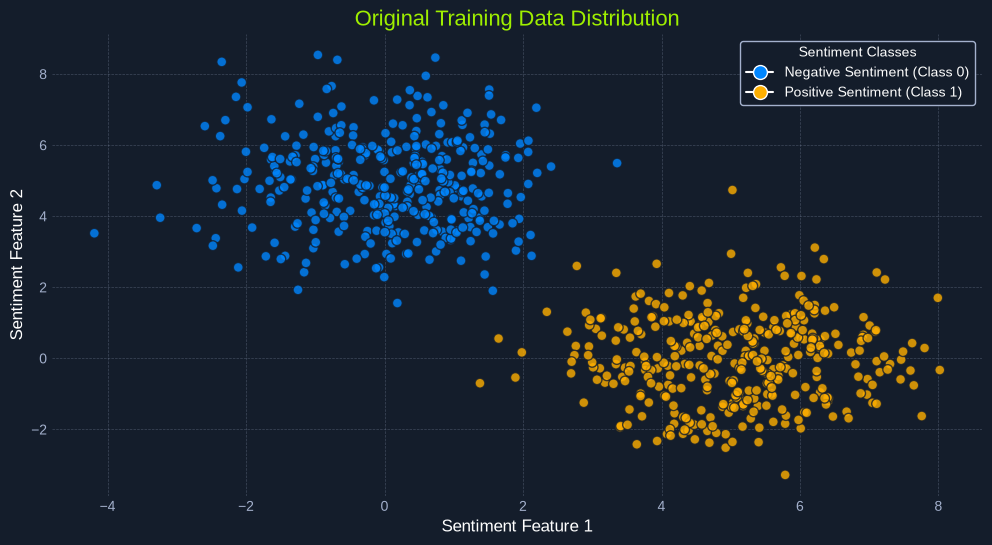

In [3]:
def plot_data(X, y, title="Dataset Visualization"):
    """
    Plots the 2D dataset with class-specific colors.

    Parameters:
    - X (np.ndarray): Feature data (n_samples, 2).
    - y (np.ndarray): Labels (n_samples,).
    - title (str): The title for the plot.
    """
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.8,
    )
    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Sentiment Feature 1", fontsize=12)
    plt.ylabel("Sentiment Feature 2", fontsize=12)
    # Create a legend
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Negative Sentiment (Class 0)", 
            markersize=10,
            markerfacecolor=azure,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Positive Sentiment (Class 1)",
            markersize=10,
            markerfacecolor=nugget_yellow,
        ),
    ]
    plt.legend(handles=handles, title="Sentiment Classes")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()


# Plot the data
plot_data(X_train, y_train, title="Original Training Data Distribution")